# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Bima Satriawan | 5054251031|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore', category=FutureWarning)


In [5]:
data = pd.read_csv('mushrooms.csv')
data.shape
data.head(10)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
5,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g
6,e,b,s,w,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,n,m
7,e,b,y,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,s,m
8,p,x,y,w,t,p,f,c,n,p,...,s,w,w,p,w,o,p,k,v,g
9,e,b,s,y,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,s,m


In [6]:
data.info()

print('Jumlah missing value: ')
print(data.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [9]:
data.duplicated().sum()

np.int64(0)

In [7]:
for col in data.columns:
    n_q = (data[col] == '?').sum()
    if n_q > 0:
        print(f"  {col}: {n_q} ({n_q/len(data)*100:.2f}%)")

  stalk-root: 2480 (30.53%)


In [10]:
unik_counts = data.nunique().sort_values(ascending=True)
print('Jumlah nilai unik per kolom:')
print(unik_counts)

print('Kolom dengan 1 nilai unik saja:')
print(unik_counts[unik_counts == 1])

Jumlah nilai unik per kolom:
veil-type                    1
class                        2
gill-attachment              2
gill-spacing                 2
stalk-shape                  2
gill-size                    2
bruises                      2
ring-number                  3
stalk-surface-above-ring     4
veil-color                   4
cap-surface                  4
stalk-surface-below-ring     4
ring-type                    5
stalk-root                   5
cap-shape                    6
population                   6
habitat                      7
odor                         9
stalk-color-above-ring       9
stalk-color-below-ring       9
spore-print-color            9
cap-color                   10
gill-color                  12
dtype: int64
Kolom dengan 1 nilai unik saja:
veil-type    1
dtype: int64


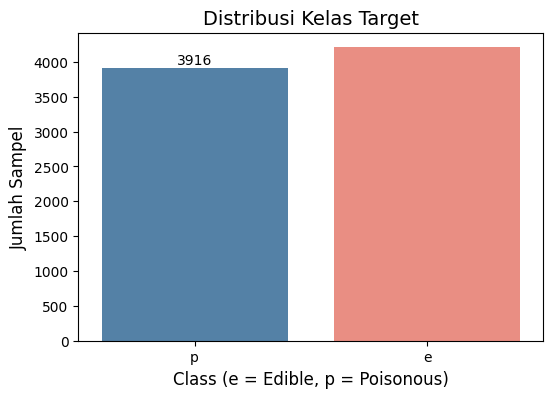

Proporsi kelas:
class
e    51.8
p    48.2
Name: proportion, dtype: float64 %


In [11]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='class', data=data, palette=['steelblue', 'salmon'])
ax.bar_label(ax.containers[0])

plt.title('Distribusi Kelas Target', fontsize=14)
plt.xlabel('Class (e = Edible, p = Poisonous)', fontsize=12)
plt.ylabel('Jumlah Sampel', fontsize=12)
plt.show()

print("Proporsi kelas:")
print(data['class'].value_counts(normalize=True).round(4) * 100, "%")

Distribusi stalk-root per kelas (%):
class           e      p
stalk-root              
?           17.11  44.94
b           45.63  47.40
c           12.17   1.12
e           20.53   6.54
r            4.56   0.00


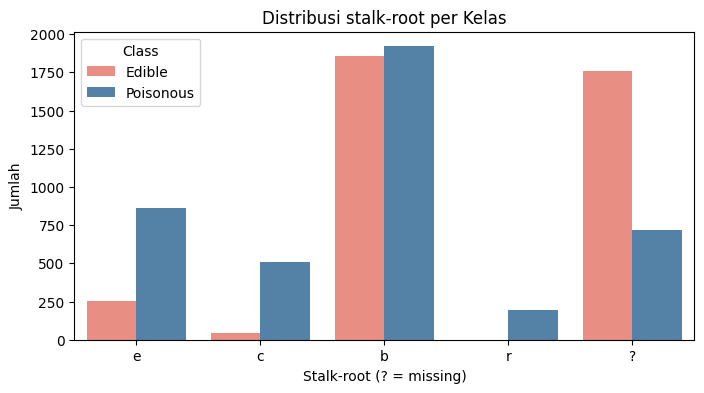

In [ ]:
ct = pd.crosstab(data['stalk-root'], data['class'], normalize='columns') * 100
print("Distribusi stalk-root per kelas (%):")
print(ct.round(2))

plt.figure(figsize=(8, 4))
sns.countplot(x='stalk-root', hue='class', data=data, palette={'e': 'steelblue', 'p': 'salmon'})
plt.title('Distribusi stalk-root per Kelas')
plt.xlabel('Stalk-root (? = missing)')
plt.ylabel('Jumlah')
plt.legend(title='Class', labels=['Edible', 'Poisonous'])
plt.show()

In [ ]:
def purity_score(feature):
    ct = pd.crosstab(data[feature], data['class'], normalize='index')
    weights = data[feature].value_counts(normalize=True)
    purity = (ct.max(axis=1) * weights).sum()
    return purity

purity = pd.Series({col: purity_score(col) for col in data.columns if col != 'class'})
print("Skor purity per fitur:")
print(purity.sort_values(ascending=False).round(4))

Skor purity per fitur (semakin tinggi = semakin informatif):
odor                        0.9852
spore-print-color           0.8680
gill-color                  0.8050
ring-type                   0.7755
stalk-surface-above-ring    0.7745
stalk-surface-below-ring    0.7661
gill-size                   0.7563
bruises                     0.7440
population                  0.7218
stalk-color-above-ring      0.7164
stalk-color-below-ring      0.7144
habitat                     0.6903
stalk-root                  0.6460
gill-spacing                0.6160
cap-color                   0.5953
cap-surface                 0.5805
cap-shape                   0.5643
stalk-shape                 0.5529
ring-number                 0.5382
veil-color                  0.5190
gill-attachment             0.5180
veil-type                   0.5180
dtype: float64


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [15]:
data['stalk-root'] = data['stalk-root'].replace('?', 'missing')

print("Distribusi stalk-root setelah penanganan:")
print(data['stalk-root'].value_counts())

Distribusi stalk-root setelah penanganan:
stalk-root
b          3776
missing    2480
e          1120
c           556
r           192
Name: count, dtype: int64


In [16]:
data = data.drop(columns=['veil-type'])

print("Shape setelah drop veil-type:", data.shape)
print("Kolom yang tersisa:", data.shape[1], "termasuk target 'class'")

Shape setelah drop veil-type: (8124, 22)
Kolom yang tersisa: 22 termasuk target 'class'


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)

X = data.drop(columns=['class'])
y = data['class']

y = y.map({'e': 0, 'p': 1})

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nDistribusi y:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nShape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print("\nProporsi kelas di y_train:")
print(y_train.value_counts(normalize=True).round(4))
print("\nProporsi kelas di y_test:")
print(y_test.value_counts(normalize=True).round(4))

Shape X: (8124, 21)
Shape y: (8124,)

Distribusi y:
class
0    4208
1    3916
Name: count, dtype: int64

Shape X_train: (6499, 21)
Shape X_test : (1625, 21)

Proporsi kelas di y_train:
class
0    0.5179
1    0.4821
Name: proportion, dtype: float64

Proporsi kelas di y_test:
class
0    0.5182
1    0.4818
Name: proportion, dtype: float64


In [22]:
# CategoricalNB butuh input integer per kategori.

ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_cat = ordinal_encoder.fit_transform(X_train)
X_test_cat = ordinal_encoder.transform(X_test)

print("Shape X_train_cat:", X_train_cat.shape)
print("Shape X_test_cat :", X_test_cat.shape)
print("\nContoh 3 baris pertama X_train_cat:")
print(X_train_cat[:3])

print("\nJumlah nilai -1 di X_train_cat:", (X_train_cat == -1).sum())
print("Jumlah nilai -1 di X_test_cat :", (X_test_cat == -1).sum())

Shape X_train_cat: (6499, 21)
Shape X_test_cat : (1625, 21)

Contoh 3 baris pertama X_train_cat:
[[ 2.  3.  9.  0.  2.  1.  0.  0.  2.  0.  0.  1.  1.  6.  0.  2.  1.  2.
   1.  5.  1.]
 [ 5.  2.  5.  1.  5.  1.  0.  0.  1.  0.  3.  2.  2.  2.  7.  2.  2.  0.
   7.  1.  6.]
 [ 0.  2.  3.  0.  5.  1.  1.  0. 10.  0.  3.  1.  2.  7.  7.  2.  2.  4.
   7.  3.  1.]]

Jumlah nilai -1 di X_train_cat: 0
Jumlah nilai -1 di X_test_cat : 0


In [23]:
# BernoulliNB dan MultinomialNB butuh representasi binary (0/1 per kategori).

onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

X_train_ohe = onehot_encoder.fit_transform(X_train)
X_test_ohe = onehot_encoder.transform(X_test)

print("Shape X_train_ohe:", X_train_ohe.shape)
print("Shape X_test_ohe :", X_test_ohe.shape)
print("\nTipe X_train_ohe:", type(X_train_ohe))
print("Jumlah fitur setelah one-hot:", X_train_ohe.shape[1])

Shape X_train_ohe: (6499, 116)
Shape X_test_ohe : (1625, 116)

Tipe X_train_ohe: <class 'scipy.sparse._csr.csr_matrix'>
Jumlah fitur setelah one-hot: 116


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [24]:
cnb = CategoricalNB(alpha=1.0)

cnb.fit(X_train_cat, y_train)

print("CategoricalNB selesai dilatih.")
print("Jumlah fitur:", cnb.n_features_in_)
print("Kelas:", cnb.classes_)

CategoricalNB selesai dilatih.
Jumlah fitur: 21
Kelas: [0 1]


In [25]:
y_pred_cnb = cnb.predict(X_test_cat)

y_proba_cnb = cnb.predict_proba(X_test_cat)[:, 1]

print("Contoh 10 prediksi label    :", y_pred_cnb[:10])
print("Contoh 10 probabilitas kelas 1:", y_proba_cnb[:10].round(4))

Contoh 10 prediksi label    : [1 0 0 1 1 0 0 0 0 0]
Contoh 10 probabilitas kelas 1: [1.     0.3692 0.     1.     1.     0.     0.     0.     0.     0.2027]


## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [26]:
bnb = BernoulliNB(alpha=1.0)

bnb.fit(X_train_ohe, y_train)

print("BernoulliNB selesai dilatih.")
print("Jumlah fitur:", bnb.n_features_in_)
print("Kelas:", bnb.classes_)

BernoulliNB selesai dilatih.
Jumlah fitur: 116
Kelas: [0 1]


In [27]:
y_pred_bnb = bnb.predict(X_test_ohe)
y_proba_bnb = bnb.predict_proba(X_test_ohe)[:, 1]

print("Contoh 10 prediksi label    :", y_pred_bnb[:10])
print("Contoh 10 probabilitas kelas 1:", y_proba_bnb[:10].round(4))

Contoh 10 prediksi label    : [1 0 0 1 1 0 0 0 0 0]
Contoh 10 probabilitas kelas 1: [1.     0.4069 0.     1.     1.     0.     0.     0.     0.     0.068 ]


## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [29]:

mnb = MultinomialNB(alpha=1.0)

# Latih pada representasi yang sama dengan Bernoulli (one-hot sparse)
mnb.fit(X_train_ohe, y_train)

print("MultinomialNB selesai dilatih.")
print("Jumlah fitur:", mnb.n_features_in_)
print("Kelas:", mnb.classes_)

MultinomialNB selesai dilatih.
Jumlah fitur: 116
Kelas: [0 1]


In [30]:
y_pred_mnb = mnb.predict(X_test_ohe)
y_proba_mnb = mnb.predict_proba(X_test_ohe)[:, 1]

print("Contoh 10 prediksi label    :", y_pred_mnb[:10])
print("Contoh 10 probabilitas kelas 1:", y_proba_mnb[:10].round(4))

Contoh 10 prediksi label    : [1 0 0 1 1 0 0 0 0 0]
Contoh 10 probabilitas kelas 1: [1.     0.3692 0.     1.     1.     0.     0.     0.     0.     0.2027]


# 4. Evaluasi Model

In [32]:
models = {
    'Categorical NB': (y_pred_cnb, y_proba_cnb),
    'Bernoulli NB': (y_pred_bnb, y_proba_bnb),
    'Multinomial NB': (y_pred_mnb, y_proba_mnb)
}

hasil = []
for nama, (y_pred, y_proba) in models.items():
    hasil.append({
        'Model': nama,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    })

df_hasil = pd.DataFrame(hasil)
print(df_hasil.to_string(index=False))

         Model  Accuracy  Precision   Recall  F1-Score      AUC
Categorical NB  0.945846   0.990127 0.896552  0.941019 0.997185
  Bernoulli NB  0.932923   0.981429 0.877395  0.926500 0.995428
Multinomial NB  0.945846   0.990127 0.896552  0.941019 0.997185


In [33]:
for nama, (y_pred, _) in models.items():
    print("=" * 60)
    print(f"Classification Report: {nama}")
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))
    print()

Classification Report: Categorical NB
              precision    recall  f1-score   support

      Edible       0.91      0.99      0.95       842
   Poisonous       0.99      0.90      0.94       783

    accuracy                           0.95      1625
   macro avg       0.95      0.94      0.95      1625
weighted avg       0.95      0.95      0.95      1625


Classification Report: Bernoulli NB
              precision    recall  f1-score   support

      Edible       0.90      0.98      0.94       842
   Poisonous       0.98      0.88      0.93       783

    accuracy                           0.93      1625
   macro avg       0.94      0.93      0.93      1625
weighted avg       0.94      0.93      0.93      1625


Classification Report: Multinomial NB
              precision    recall  f1-score   support

      Edible       0.91      0.99      0.95       842
   Poisonous       0.99      0.90      0.94       783

    accuracy                           0.95      1625
   macro avg  

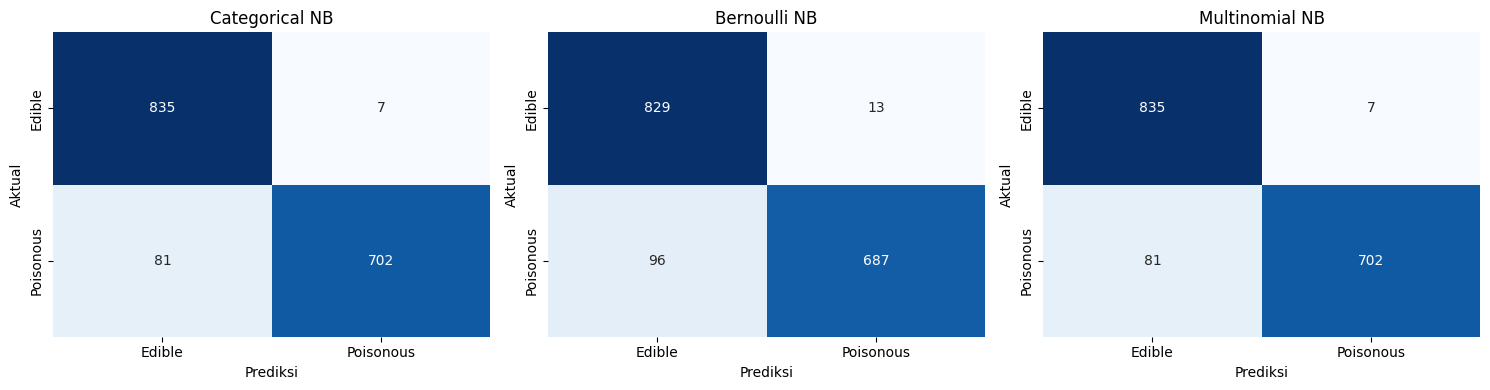

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nama, (y_pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Edible', 'Poisonous'],
        yticklabels=['Edible', 'Poisonous'],
        ax=ax, cbar=False
    )
    ax.set_title(nama)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.show()

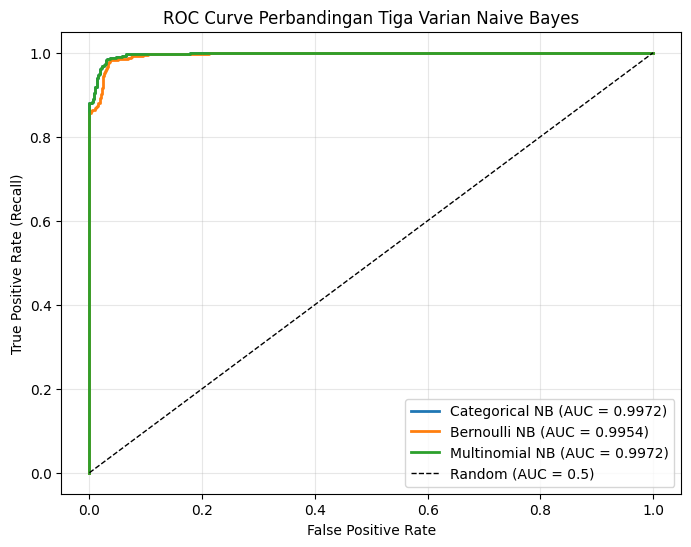


AUC tiap model:
  Categorical NB: 0.9972
  Bernoulli NB: 0.9954
  Multinomial NB: 0.9972


In [35]:
plt.figure(figsize=(8, 6))

for nama, (_, y_proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nama} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Perbandingan Tiga Varian Naive Bayes')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Cetak AUC
print("\nAUC tiap model:")
for nama, (_, y_proba) in models.items():
    print(f"  {nama}: {roc_auc_score(y_test, y_proba):.4f}")

# 5. Analisis

### Analisis Hasil Eksperimen

**1. Perbandingan performa tiga varian.**

CategoricalNB dan MultinomialNB menghasilkan performa yang identik di seluruh metrik: accuracy 0.9458, precision poisonous 0.9901, recall poisonous 0.8966, F1 0.9410, dan AUC 0.9972. BernoulliNB tertinggal tipis di semua metrik: accuracy 0.9329, recall poisonous 0.8774, AUC 0.9954. Meskipun selisihnya kecil (~1.3 poin akurasi), pola konsisten di semua metrik menunjukkan perbedaan ini bukan kebetulan.

**2. Mengapa CategoricalNB dan MultinomialNB identik.**

OneHotEncoder menghasilkan matriks biner di mana setiap baris hanya memiliki tepat satu nilai 1 per fitur asli (karena setiap sampel hanya punya satu kategori per fitur). Dalam kondisi ini, MultinomialNB yang menghitung P(kategori | kelas) sebagai rasio frekuensi menjadi ekuivalen secara matematis dengan CategoricalNB yang menghitung P(fitur=kategori | kelas) secara langsung. Keduanya tidak memperhitungkan absensi; hanya kehadiran. Ini menjelaskan mengapa prediksi label dan probabilitas keduanya identik sampai 4 desimal.

**3. Mengapa BernoulliNB tertinggal.**

BernoulliNB berbeda secara fundamental: dia memperhitungkan absensi (kolom bernilai 0) sebagai sinyal. Setiap kolom yang tidak aktif dihitung sebagai bukti "kategori ini tidak ada", Dalam dataset ini, karena setiap fitur asli hanya punya satu kategori aktif per sampel, kolom-kolom 0 hanyalah "kategori lain yang tidak terpilih", bukan informasi bahwa fitur itu absen. BernoulliNB memperlakukan ini sebagai sinyal, yang justru menambah noise dan sedikit menurunkan performa.

**4. Analisis kesalahan (confusion matrix).**

Kesalahan dominan di ketiga model adalah false negative jamur poisonous diprediksi edible. CategoricalNB: 81 FN, BernoulliNB: 96 FN, MultinomialNB: 81 FN. Dalam konteks identifikasi jamur, false negative jauh lebih berbahaya dari false positive: jamur beracun yang lolos bisa berakibat fatal, sementara jamur edible yang salah ditandai poisonous hanya membuat orang membuang jamur yang sebenarnya aman. Precision poisonous yang tinggi (0.98–0.99) menandakan model sangat bisa dipercaya ketika memprediksi poisonous; kelemahannya ada di recall.

**5. Kualitas ranking (AUC).**

Ketiga model memiliki AUC di atas 0.99, menandakan kualitas ranking probabilitas yang sangat baik. ROC curve hampir menempel di sudut kiri atas. Ini berarti threshold tuning berpotensi besar: menurunkan threshold untuk poisonous bisa meningkatkan recall secara signifikan tanpa mengorbankan precision secara berlebihan.

**6. Faktor pendukung performa tinggi.**

Dataset Mushroom memiliki fitur `odor` dengan purity score 0.9852. Fitur ini sendiri sudah hampir cukup untuk memisahkan kelas. Ini menjelaskan mengapa ketiga varian NB, terlepas dari perbedaan representasi, semuanya mencapai akurasi di atas 93%. Perbedaan antar model hanya muncul di margin, ketika harus menangani kasus-kasus ambigu di mana sinyal odor tidak cukup kuat.

# 6. Kesimpulan dan Saran

### Kesimpulan

1. Ketiga varian Naive Bayes berhasil mengklasifikasikan jamur edible vs poisonous dengan akurasi di atas 93%. CategoricalNB dan MultinomialNB memimpin dengan 94.58%, diikuti BernoulliNB dengan 93.29%.

2. CategoricalNB dan MultinomialNB menghasilkan hasil identik karena representasi OneHotEncoder pada data dengan satu kategori aktif per fitur membuat kedua model menjadi ekuivalen secara matematis.

3. BernoulliNB tertinggal tipis karena memperhitungkan absensi kategori sebagai sinyal, yang justru menambah noise dalam struktur data seperti Mushroom di mana setiap fitur hanya punya satu kategori aktif.

4. CategoricalNB adalah pilihan paling natural untuk dataset ini karena fitur memang kategorikal murni. Selain performa terbaik, model ini tidak memerlukan transformasi one-hot yang melonjakkan dimensi dari 21 menjadi 116 kolom.

5. Dalam konteks aplikasi nyata, false negative (jamur beracun diprediksi edible) adalah kesalahan paling berbahaya. Model saat ini menghasilkan 81 FN dari 783 jamur beracun (~10%). Untuk sistem yang aman, threshold perlu diturunkan untuk menekan FN, dengan konsekuensi lebih banyak false positive.

### Saran

1. **Threshold tuning.** Karena AUC ketiga model sangat tinggi (>0.99), tuning threshold berpotensi besar. Gunakan precision-recall curve untuk memilih threshold yang menekan false negative, misalnya threshold 0.3 atau 0.4 untuk kelas poisonous.
